In [1]:
import numpy as np

# 1. 形状为 3×4 的随机矩阵 X，元素服从标准正态分布
X = np.random.randn(3, 4)
print("X:\n", X)

# 2. 形状为 4×2 的全 1 矩阵 Y
Y = np.ones((4, 2))
print("Y:\n", Y)

# 3. 矩阵乘法 Z = X @ Y
Z = X @ Y
print("Z:\n", Z)

# 4. 输出 Z 的第一行和第二列交叉处的元素（注意索引从0开始）
element = Z[0, 1]   # 第一行索引0，第二列索引1
print("Z[0,1]:", element)

# 以及 Z 的第 2 行所有元素（索引1）
row_2 = Z[1, :]
print("Z 第2行:", row_2)

# 5. 计算 Z 的 Frobenius 范数
fro_norm = np.linalg.norm(Z, 'fro')
print("Frobenius norm of Z:", fro_norm)

X:
 [[-0.48635912 -0.16522392 -2.05819108  0.1863155 ]
 [-1.30136693  0.57761385  2.85235588  1.46903557]
 [ 0.38582099 -0.1592285   0.491183   -0.18448797]]
Y:
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
Z:
 [[-2.52345862 -2.52345862]
 [ 3.59763837  3.59763837]
 [ 0.53328752  0.53328752]]
Z[0,1]: -2.52345861907117
Z 第2行: [3.59763837 3.59763837]
Frobenius norm of Z: 6.260230160653844


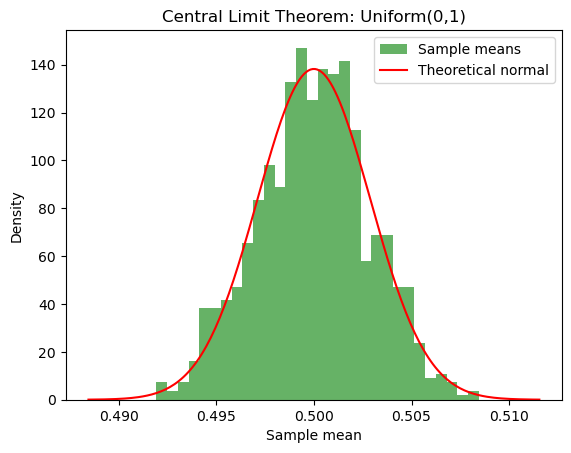

Actual variance of sample means: 8.283920931442144e-06
Theoretical variance: 8.333333333333332e-06


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)
n = 10000      # 每次抽取的样本量
m = 1000       # 重复次数

# 1. 生成 m 次均值
means = np.array([np.random.uniform(0, 1, n).mean() for _ in range(m)])

# 2. 绘制直方图并叠加理论正态分布曲线
plt.hist(means, bins=30, density=True, alpha=0.6, color='g', label='Sample means')

# 理论正态分布：均值为0.5，方差为均匀分布方差/n = (1/12)/n
mu_theory = 0.5
sigma_theory = np.sqrt((1/12) / n)
x = np.linspace(mu_theory - 4*sigma_theory, mu_theory + 4*sigma_theory, 200)
plt.plot(x, norm.pdf(x, mu_theory, sigma_theory), 'r-', label='Theoretical normal')

plt.xlabel('Sample mean')
plt.ylabel('Density')
plt.title('Central Limit Theorem: Uniform(0,1)')
plt.legend()
plt.show()

# 3. 计算这些均值的实际方差
actual_var = np.var(means, ddof=1)   # 样本方差，ddof=1 为无偏估计
print("Actual variance of sample means:", actual_var)
print("Theoretical variance:", 1/12 / n)

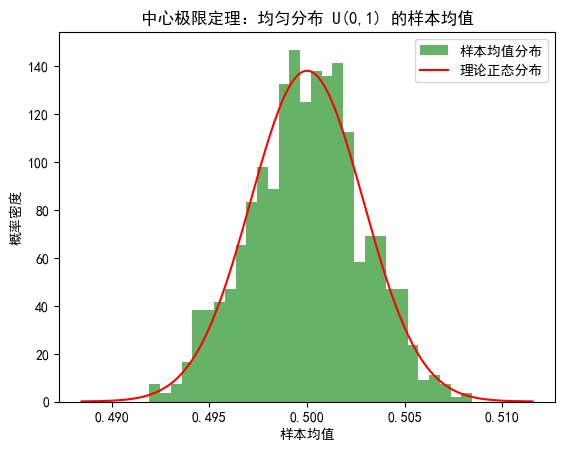

样本均值的实际方差: 8.283920931442144e-06
理论方差: 8.333333333333332e-06


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 设置中文字体（Windows 用 SimHei，macOS 用 PingFang SC 或 Heiti SC）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 或者 ['PingFang SC', 'Heiti SC']
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

np.random.seed(42)
n = 10000      # 每次抽取的样本量
m = 1000       # 重复次数

# 1. 生成 m 次均值
means = np.array([np.random.uniform(0, 1, n).mean() for _ in range(m)])

# 2. 绘制直方图并叠加理论正态分布曲线
plt.hist(means, bins=30, density=True, alpha=0.6, color='g', label='样本均值分布')

# 理论正态分布：均值为0.5，方差为均匀分布方差/n = (1/12)/n
mu_theory = 0.5
sigma_theory = np.sqrt((1/12) / n)
x = np.linspace(mu_theory - 4*sigma_theory, mu_theory + 4*sigma_theory, 200)
plt.plot(x, norm.pdf(x, mu_theory, sigma_theory), 'r-', label='理论正态分布')

plt.xlabel('样本均值')
plt.ylabel('概率密度')
plt.title('中心极限定理：均匀分布 U(0,1) 的样本均值')
plt.legend()
plt.show()

# 3. 计算这些均值的实际方差
actual_var = np.var(means, ddof=1)   # 样本方差，ddof=1 为无偏估计
print("样本均值的实际方差:", actual_var)
print("理论方差:", 1/12 / n)

In [8]:
import torch

# 给定值
x = 2.0
w1 = 1.5
w2 = 0.5

# ---- 前向计算 ----
a = x * w1
b = a + w2
L = b ** 2
print(f"Forward: a={a}, b={b}, L={L}")

# ---- 手动反向传播 ----
# L = b^2  => dL/db = 2b
# b = a + w2 => da/dw1? 实际上我们需要 dL/dw1, dL/dw2
# 链式法则：
# dL/dw1 = dL/db * db/da * da/dw1
# dL/db = 2b
# db/da = 1
# da/dw1 = x
# 所以 dL/dw1 = 2b * 1 * x = 2 * b * x
# dL/dw2 = dL/db * db/dw2 = 2b * 1 = 2b

b_val = b   # 注意 b 是数值，不是张量
grad_w1_manual = 2 * b_val * x
grad_w2_manual = 2 * b_val
print(f"Manual gradient: dL/dw1 = {grad_w1_manual}, dL/dw2 = {grad_w2_manual}")

# ---- PyTorch 自动微分验证 ----
x_t = torch.tensor(x, dtype=torch.float32)
w1_t = torch.tensor(w1, requires_grad=True)
w2_t = torch.tensor(w2, requires_grad=True)

a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2
L_t.backward()

print(f"Torch gradient: dL/dw1 = {w1_t.grad.item()}, dL/dw2 = {w2_t.grad.item()}")

Forward: a=3.0, b=3.5, L=12.25
Manual gradient: dL/dw1 = 14.0, dL/dw2 = 7.0
Torch gradient: dL/dw1 = 14.0, dL/dw2 = 7.0


In [4]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# 1. 加载数据
digits = load_digits()
X = digits.data / 16.0          # 简单归一化到 [0,1]
y = digits.target.reshape(-1, 1)

# 2. One-hot 编码
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)
n_samples, n_features = X_train.shape
n_classes = y_train.shape[1]

# 3. Softmax 函数
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # 防止溢出
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# 交叉熵损失
def cross_entropy_loss(y_pred, y_true):
    m = y_true.shape[0]
    loss = -np.sum(y_true * np.log(y_pred + 1e-8)) / m
    return loss

# 初始化参数
np.random.seed(0)
W = np.random.randn(n_features, n_classes) * 0.01
b = np.zeros((1, n_classes))

# 4. 小批量 SGD 训练
batch_size = 32
learning_rate = 0.1
epochs = 50

for epoch in range(epochs):
    # 打乱数据
    indices = np.random.permutation(n_samples)
    X_shuffled = X_train[indices]
    y_shuffled = y_train[indices]
    
    for i in range(0, n_samples, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        
        # 前向
        logits = X_batch @ W + b
        y_pred = softmax(logits)
        
        # 梯度计算
        m = X_batch.shape[0]
        grad_logits = (y_pred - y_batch) / m
        grad_W = X_batch.T @ grad_logits
        grad_b = np.sum(grad_logits, axis=0, keepdims=True)
        
        # 更新
        W -= learning_rate * grad_W
        b -= learning_rate * grad_b
    
    # 每个 epoch 计算一次训练损失（可选）
    if (epoch+1) % 10 == 0:
        logits_train = X_train @ W + b
        y_pred_train = softmax(logits_train)
        loss = cross_entropy_loss(y_pred_train, y_train)
        print(f"Epoch {epoch+1}, loss: {loss:.4f}")

# 5. 测试集准确率
logits_test = X_test @ W + b
y_pred_test = softmax(logits_test)
y_pred_labels = np.argmax(y_pred_test, axis=1)
y_true_labels = np.argmax(y_test, axis=1)
accuracy = np.mean(y_pred_labels == y_true_labels)
print(f"Test accuracy: {accuracy:.4f}")

Epoch 10, loss: 0.4394
Epoch 20, loss: 0.2938
Epoch 30, loss: 0.2372
Epoch 40, loss: 0.2047
Epoch 50, loss: 0.1833
Test accuracy: 0.9583


Iteration 200, loss: 0.3054
Iteration 400, loss: 0.2103
Iteration 600, loss: 0.1667
Iteration 800, loss: 0.1418
Iteration 1000, loss: 0.1255


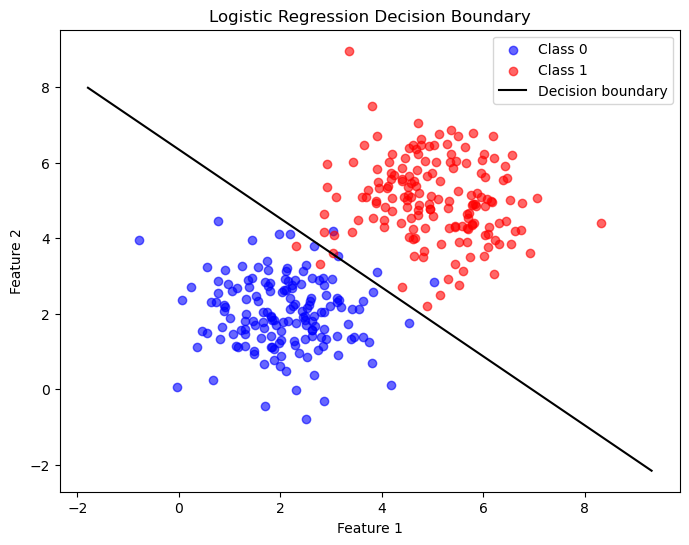

Test accuracy: 0.9750


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 生成线性可分数据
np.random.seed(1)
n_per_class = 200
# 类别 0
mean0 = [2, 2]
cov0 = [[1, 0], [0, 1]]
X0 = np.random.multivariate_normal(mean0, cov0, n_per_class)
y0 = np.zeros(n_per_class)

# 类别 1
mean1 = [5, 5]
cov1 = [[1, 0], [0, 1]]
X1 = np.random.multivariate_normal(mean1, cov1, n_per_class)
y1 = np.ones(n_per_class)

X = np.vstack([X0, X1])
y = np.hstack([y0, y1]).reshape(-1, 1)

# 划分训练/测试
indices = np.random.permutation(len(X))
split = int(0.8 * len(X))
train_idx, test_idx = indices[:split], indices[split:]
X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

# 2. Sigmoid 函数
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 二元交叉熵损失
def binary_cross_entropy(y_pred, y_true):
    eps = 1e-8
    return -np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))

# 3. 梯度下降
n_samples, n_features = X_train.shape
W = np.random.randn(n_features, 1) * 0.01
b = 0.0
lr = 0.1
n_iter = 1000

loss_history = []
for i in range(n_iter):
    # 前向
    z = X_train @ W + b
    y_pred = sigmoid(z)
    loss = binary_cross_entropy(y_pred, y_train)
    loss_history.append(loss)
    
    # 梯度
    m = len(y_train)
    dz = (y_pred - y_train) / m
    dW = X_train.T @ dz
    db = np.sum(dz)
    
    # 更新
    W -= lr * dW
    b -= lr * db
    
    if (i+1) % 200 == 0:
        print(f"Iteration {i+1}, loss: {loss:.4f}")

# 4. 绘制决策边界
plt.figure(figsize=(8,6))
# 绘制训练数据点
plt.scatter(X_train[y_train.flatten()==0, 0], X_train[y_train.flatten()==0, 1], 
            c='blue', label='Class 0', alpha=0.6)
plt.scatter(X_train[y_train.flatten()==1, 0], X_train[y_train.flatten()==1, 1], 
            c='red', label='Class 1', alpha=0.6)

# 决策边界：W1*x1 + W2*x2 + b = 0 => x2 = -(W1*x1 + b)/W2
x1_vals = np.linspace(X_train[:,0].min()-1, X_train[:,0].max()+1, 100)
x2_vals = -(W[0,0] * x1_vals + b) / W[1,0]
plt.plot(x1_vals, x2_vals, 'k-', label='Decision boundary')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.show()

# 测试集准确率
z_test = X_test @ W + b
y_test_pred = sigmoid(z_test) >= 0.5
accuracy = np.mean(y_test_pred == y_test)
print(f"Test accuracy: {accuracy:.4f}")

迭代 200，损失: 0.3054
迭代 400，损失: 0.2103
迭代 600，损失: 0.1667
迭代 800，损失: 0.1418
迭代 1000，损失: 0.1255


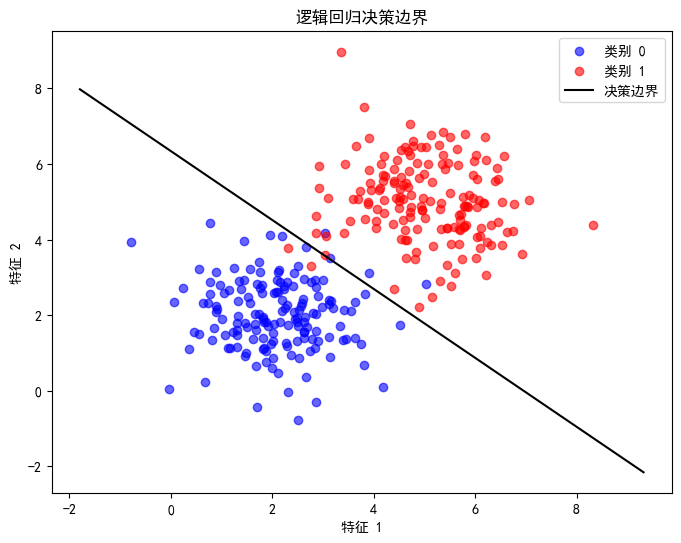

测试集准确率: 0.9750


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 或者 ['PingFang SC', 'Heiti SC']
plt.rcParams['axes.unicode_minus'] = False

# 1. 生成线性可分数据
np.random.seed(1)
n_per_class = 200
# 类别 0
mean0 = [2, 2]
cov0 = [[1, 0], [0, 1]]
X0 = np.random.multivariate_normal(mean0, cov0, n_per_class)
y0 = np.zeros(n_per_class)

# 类别 1
mean1 = [5, 5]
cov1 = [[1, 0], [0, 1]]
X1 = np.random.multivariate_normal(mean1, cov1, n_per_class)
y1 = np.ones(n_per_class)

X = np.vstack([X0, X1])
y = np.hstack([y0, y1]).reshape(-1, 1)

# 划分训练/测试
indices = np.random.permutation(len(X))
split = int(0.8 * len(X))
train_idx, test_idx = indices[:split], indices[split:]
X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

# 2. Sigmoid 函数
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 二元交叉熵损失
def binary_cross_entropy(y_pred, y_true):
    eps = 1e-8
    return -np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))

# 3. 梯度下降
n_samples, n_features = X_train.shape
W = np.random.randn(n_features, 1) * 0.01
b = 0.0
lr = 0.1
n_iter = 1000

loss_history = []
for i in range(n_iter):
    # 前向
    z = X_train @ W + b
    y_pred = sigmoid(z)
    loss = binary_cross_entropy(y_pred, y_train)
    loss_history.append(loss)
    
    # 梯度
    m = len(y_train)
    dz = (y_pred - y_train) / m
    dW = X_train.T @ dz
    db = np.sum(dz)
    
    # 更新
    W -= lr * dW
    b -= lr * db
    
    if (i+1) % 200 == 0:
        print(f"迭代 {i+1}，损失: {loss:.4f}")

# 4. 绘制决策边界
plt.figure(figsize=(8,6))
# 绘制训练数据点
plt.scatter(X_train[y_train.flatten()==0, 0], X_train[y_train.flatten()==0, 1], 
            c='blue', label='类别 0', alpha=0.6)
plt.scatter(X_train[y_train.flatten()==1, 0], X_train[y_train.flatten()==1, 1], 
            c='red', label='类别 1', alpha=0.6)

# 决策边界：W1*x1 + W2*x2 + b = 0 => x2 = -(W1*x1 + b)/W2
x1_vals = np.linspace(X_train[:,0].min()-1, X_train[:,0].max()+1, 100)
x2_vals = -(W[0,0] * x1_vals + b) / W[1,0]
plt.plot(x1_vals, x2_vals, 'k-', label='决策边界')

plt.xlabel('特征 1')
plt.ylabel('特征 2')
plt.title('逻辑回归决策边界')
plt.legend()
plt.show()

# 测试集准确率
z_test = X_test @ W + b
y_test_pred = sigmoid(z_test) >= 0.5
accuracy = np.mean(y_test_pred == y_test)
print(f"测试集准确率: {accuracy:.4f}")